In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load all results
base_dir = Path("/home/xiruij/anticipation/exp_causal_similarity")
seeds = [0, 1, 2, 3, 4]
test_idx = 114

all_results = []
for seed in seeds:
    result_file = base_dir / f"seed_{seed}_test_{test_idx}" / "results.json"
    with open(result_file, "r") as f:
        all_results.append(json.load(f))

print(f"Loaded {len(all_results)} results")


Loaded 5 results


In [13]:
# Extract NLL increase (compared to full model)
ks = [100, 500]
models = ["full", "removed_random", "removed_hals"]
model_labels = ["Full", "Random Removal", "HA-LS Removal"]

# Collect NLL increase for each K and model
nll_increases = {k: {m: [] for m in models} for k in ks}

for result in all_results:
    for k in ks:
        k_key = f"k_{k}"
        full_nll = result["results"][k_key]["full"]["nll_mean"]
        for model in models:
            model_nll = result["results"][k_key][model]["nll_mean"]
            nll_increase = model_nll - full_nll
            nll_increases[k][model].append(nll_increase)

# Print summary table
print("NLL Increase (compared to full model):")
print("="*70)
print(f"{'K':>6} | {'Model':>20} | {'Mean':>10} | {'Std':>10}")
print("-"*70)
for k in ks:
    for model, label in zip(models, model_labels):
        values = nll_increases[k][model]
        mean = np.mean(values)
        std = np.std(values)
        print(f"{k:>6} | {label:>20} | {mean:>10.4f} | {std:>10.4f}")
    print("-"*70)


NLL Increase (compared to full model):
     K |                Model |       Mean |        Std
----------------------------------------------------------------------
   100 |                 Full |     0.0000 |     0.0000
   100 |       Random Removal |    -0.0191 |     0.0298
   100 |        HA-LS Removal |     0.0692 |     0.0124
----------------------------------------------------------------------
   500 |                 Full |     0.0000 |     0.0000
   500 |       Random Removal |     0.0104 |     0.0387
   500 |        HA-LS Removal |     0.0589 |     0.0256
----------------------------------------------------------------------


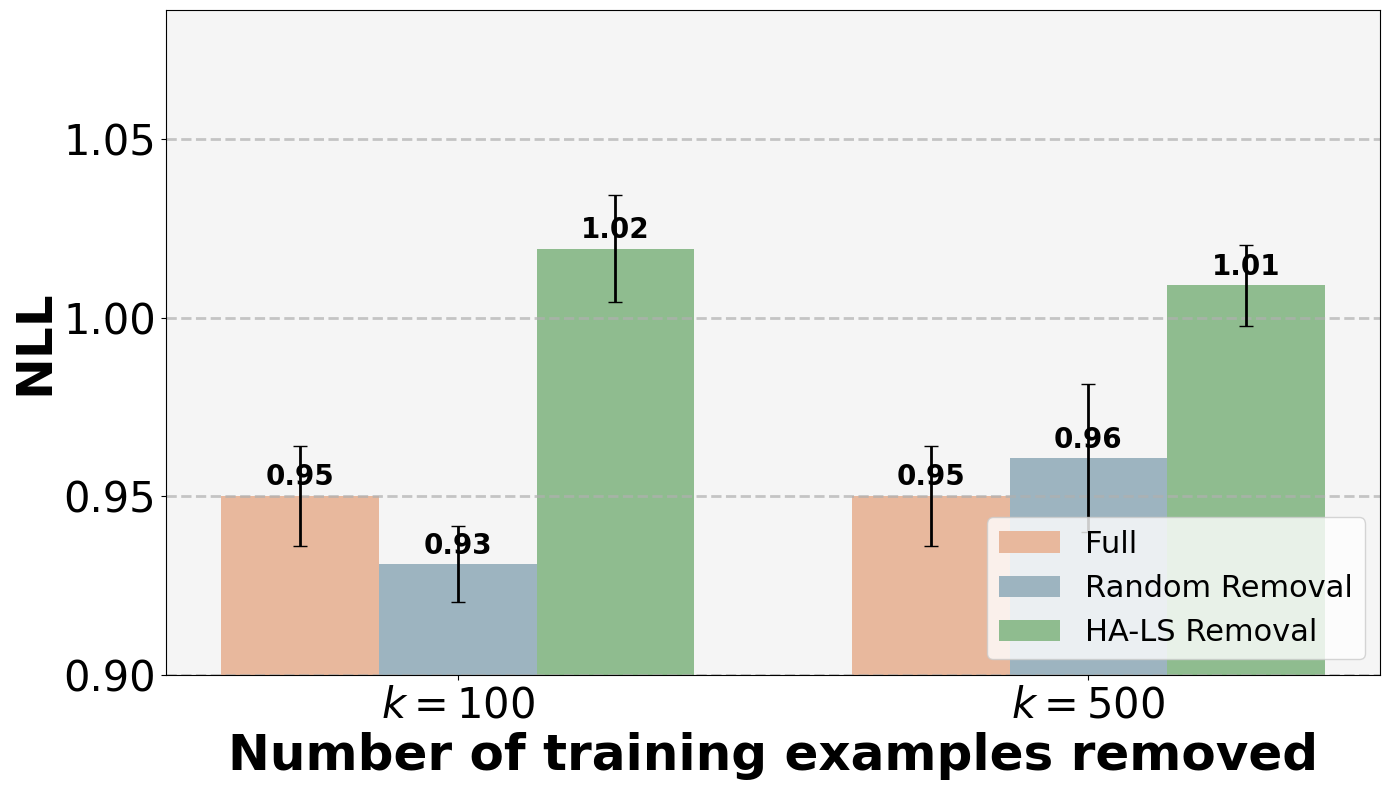

Saved to causal_similarity_nll.pdf


In [14]:
# Plot: NLL Bar Chart (absolute values, 3 bars per K)
fig, ax = plt.subplots(figsize=(14, 8))

# Collect NLL values (not increases)
nll_values = {k: {m: [] for m in models} for k in ks}
for result in all_results:
    for k in ks:
        k_key = f"k_{k}"
        for model in models:
            nll = result["results"][k_key][model]["nll_mean"]
            nll_values[k][model].append(nll)

# Colors for 3 models
colors_3 = ['#E8B89D', '#9DB4C0', '#8FBC8F']  # salmon, steel blue, sea green
plot_models_3 = ["full", "removed_random", "removed_hals"]
plot_labels_3 = ["Full", "Random Removal", "HA-LS Removal"]

x = np.arange(len(ks))
width = 0.25
n_models = len(plot_models_3)

for i, (model, label, color) in enumerate(zip(plot_models_3, plot_labels_3, colors_3)):
    means = [np.mean(nll_values[k][model]) for k in ks]
    sems = [np.std(nll_values[k][model]) / np.sqrt(len(nll_values[k][model])) for k in ks]
    
    offset = (i - (n_models - 1) / 2) * width
    bars = ax.bar(x + offset, means, width, label=label, color=color, 
                  yerr=sems, capsize=5, error_kw={'linewidth': 2})
    
    for bar, mean in zip(bars, means):
        height = bar.get_height()
        ax.annotate(f'{mean:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=20, fontweight='bold')

ax.set_ylabel('NLL', fontsize=36, fontweight='bold')
ax.set_xlabel('Number of training examples removed', fontsize=36, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'$k = {k}$' for k in ks], fontsize=30)
ax.tick_params(axis='y', labelsize=30)
ax.legend(fontsize=22, loc='lower right')
ax.set_ylim(bottom=0.9)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, linewidth=2)
ax.set_facecolor('#F5F5F5')

plt.tight_layout()
plt.savefig('/home/xiruij/anticipation/causal_similarity_nll.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to causal_similarity_nll.pdf")


In [15]:
# PPL summary table
ppl_values = {k: {m: [] for m in models} for k in ks}

for result in all_results:
    for k in ks:
        k_key = f"k_{k}"
        for model in models:
            ppl = result["results"][k_key][model]["ppl"]
            ppl_values[k][model].append(ppl)

print("\nPerplexity (PPL) values:")
print("="*70)
print(f"{'K':>6} | {'Model':>20} | {'Mean PPL':>10} | {'Std':>10}")
print("-"*70)
for k in ks:
    for model, label in zip(models, model_labels):
        values = ppl_values[k][model]
        mean = np.mean(values)
        std = np.std(values)
        print(f"{k:>6} | {label:>20} | {mean:>10.4f} | {std:>10.4f}")
    print("-"*70)



Perplexity (PPL) values:
     K |                Model |   Mean PPL |        Std
----------------------------------------------------------------------
   100 |                 Full |     2.5874 |     0.0819
   100 |       Random Removal |     2.5380 |     0.0593
   100 |        HA-LS Removal |     2.7731 |     0.0941
----------------------------------------------------------------------
   500 |                 Full |     2.5874 |     0.0819
   500 |       Random Removal |     2.6160 |     0.1189
   500 |        HA-LS Removal |     2.7439 |     0.0696
----------------------------------------------------------------------


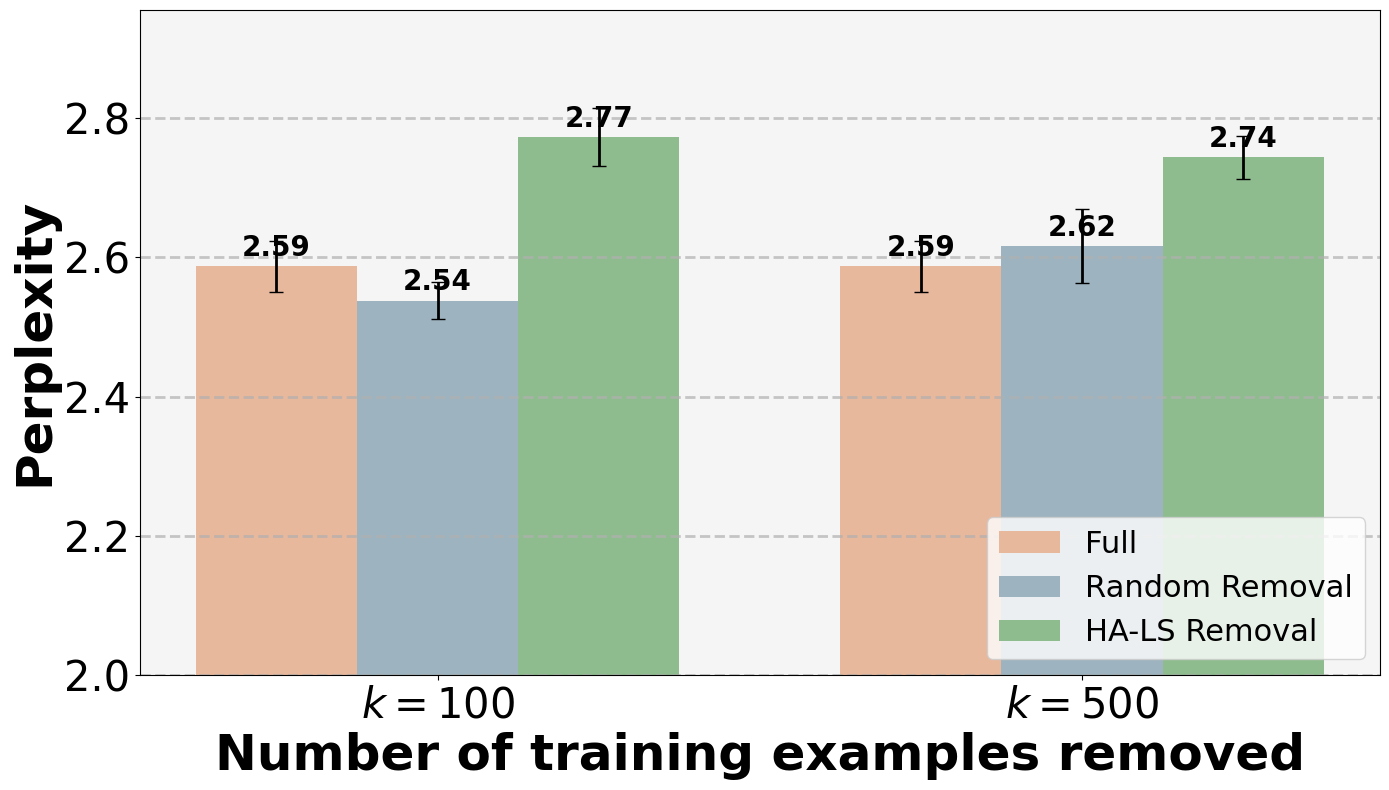

Saved to causal_similarity_ppl.pdf


In [16]:
# Plot: PPL Bar Chart (absolute values, 3 bars per K)
fig, ax = plt.subplots(figsize=(14, 8))

# Colors for 3 models
colors_3 = ['#E8B89D', '#9DB4C0', '#8FBC8F']  # salmon, steel blue, sea green
plot_models_3 = ["full", "removed_random", "removed_hals"]
plot_labels_3 = ["Full", "Random Removal", "HA-LS Removal"]

x = np.arange(len(ks))
width = 0.25
n_models = len(plot_models_3)

for i, (model, label, color) in enumerate(zip(plot_models_3, plot_labels_3, colors_3)):
    means = [np.mean(ppl_values[k][model]) for k in ks]
    sems = [np.std(ppl_values[k][model]) / np.sqrt(len(ppl_values[k][model])) for k in ks]
    
    offset = (i - (n_models - 1) / 2) * width
    bars = ax.bar(x + offset, means, width, label=label, color=color, 
                  yerr=sems, capsize=5, error_kw={'linewidth': 2})
    
    for bar, mean in zip(bars, means):
        height = bar.get_height()
        ax.annotate(f'{mean:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=20, fontweight='bold')

ax.set_ylabel('Perplexity', fontsize=36, fontweight='bold')
ax.set_xlabel('Number of training examples removed', fontsize=36, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'$k = {k}$' for k in ks], fontsize=30)
ax.tick_params(axis='y', labelsize=30)
ax.legend(fontsize=22, loc='lower right')
ax.set_ylim(bottom=2)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, linewidth=2)
ax.set_facecolor('#F5F5F5')

plt.tight_layout()
plt.savefig('/home/xiruij/anticipation/causal_similarity_ppl.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to causal_similarity_ppl.pdf")
